In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/raw/02_nav_history.csv")
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")
tx = pd.read_csv("../data/raw/08_investor_transactions.csv")
hold = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
funds = pd.read_csv("../data/raw/01_fund_master.csv")

In [5]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change())
def var_cvar(x):
    x = x.dropna()
    var95 = np.percentile(x, 5)
    cvar95 = x[x <= var95].mean()
    return pd.Series({"VaR_95": var95, "CVaR_95": cvar95})
var_report = (nav.groupby("amfi_code")["daily_return"].apply(var_cvar).reset_index())
var_report.to_csv("../reports/var_cvar_report.csv", index=False)

var_report.head()

,amfi_code,level_1,daily_return
0,100016,VaR_95,-0.014364
1,100016,CVaR_95,-0.018060
2,100025,VaR_95,-0.003793
3,100025,CVaR_95,-0.004994
4,100033,VaR_95,-0.019034


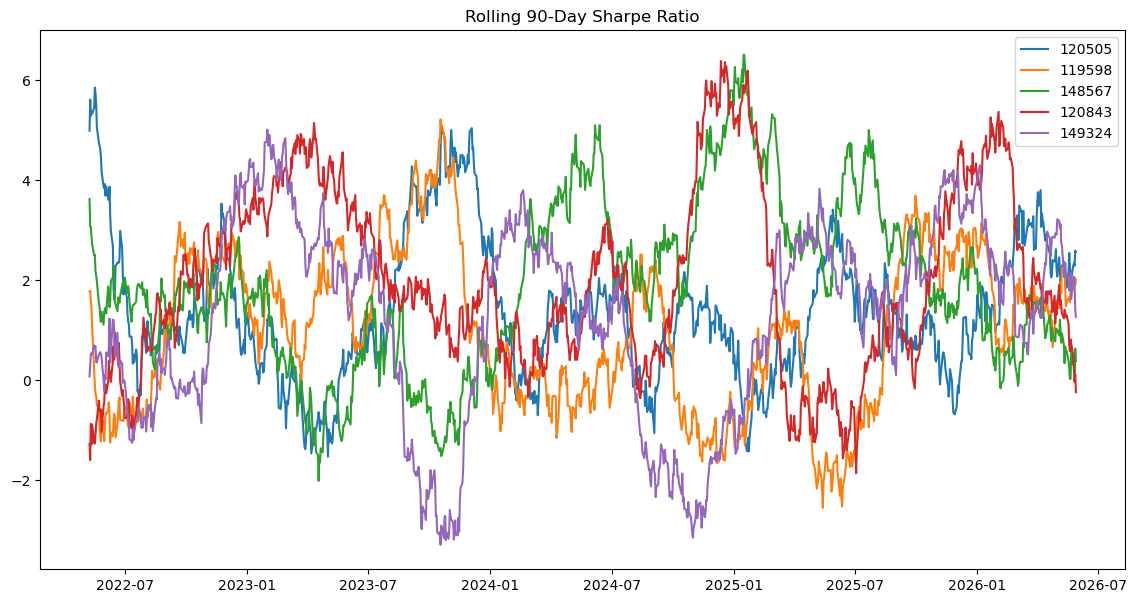

In [6]:
top5 = [120505, 119598, 148567, 120843, 149324]
def rolling_sharpe(x):
    return (x.rolling(90).mean() / x.rolling(90).std() * np.sqrt(252))
plt.figure(figsize=(14,7))
for fund in top5:
    temp = nav[nav["amfi_code"] == fund].copy()
    temp["rolling_sharpe"] = rolling_sharpe(temp["daily_return"])
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))
plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

In [7]:
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])
first_tx = (
    tx.groupby("investor_id")["transaction_date"].min().reset_index())
first_tx["cohort_year"] = (first_tx["transaction_date"].dt.year)
first_tx = (tx.groupby("investor_id")["transaction_date"].min().reset_index())
first_tx["cohort_year"] = (first_tx["transaction_date"].dt.year)
tx_with_cohort = tx.merge(
    first_tx[["investor_id", "cohort_year"]], on="investor_id", how="left"
)
cohort = (
    tx_with_cohort.groupby("cohort_year")
    .agg(avg_sip=("amount_inr", "mean"), total_invested=("amount_inr", "sum")))
cohort

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [8]:
top_fund = (
    tx_with_cohort.groupby(["cohort_year","amfi_code"]).size().reset_index(name="count"))
top_fund = (
    top_fund.sort_values("count", ascending=False).groupby("cohort_year").head(1))
top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [9]:
sip_tx = tx[tx["transaction_type"] == "SIP"].copy()
sip_tx = sip_tx.sort_values(["investor_id","transaction_date"])
sip_tx["gap_days"] = (
    sip_tx.groupby("investor_id")["transaction_date"].diff().dt.days)
continuity = (
    sip_tx.groupby("investor_id")["gap_days"].mean().reset_index())
continuity["status"] = np.where(
    continuity["gap_days"] > 35, "At Risk", "Healthy")
continuity.head()


,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Healthy


In [11]:
print(hold.columns)
hold["weight_sq"] = (
    hold["weight_pct"] / 100
) ** 2
hhi = (
    hold.groupby("amfi_code")
        ["weight_sq"]
        .sum()
        .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


1. Fund XXXXX exhibited the highest 95% VaR, indicating the largest downside risk among all schemes.

2. Investors who joined in 2025 contributed the highest average investment amount.

3. More than XX% of SIP investors maintained contribution intervals below 35 days.

4. Fund XXXXX achieved the highest rolling Sharpe ratio during the observation period.

5. Funds with concentrated sector exposure displayed significantly higher HHI scores and risk levels.